In [66]:
# imports

import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.utils import Progbar # pyright: ignore[reportMissingImports]
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.stats import binned_statistic
from matplotlib.colors import LogNorm

In [67]:
#pytorch data shard and numpy savez inspection 

y_stats = np.load('../data/y_stats.npz')

y_stats.files

['mean', 'std']

In [68]:
y_stats['std']

array([[3242.1875  ,   81.052155]], dtype=float32)

In [69]:
y_stats['mean']

array([[237.14874  ,   5.9275894]], dtype=float32)

In [70]:
data = torch.load('../data/train/train_00000.pt')

data

{'X': tensor([[[0.0000e+00, 4.8840e-04, 4.1514e-03,  ..., 9.5238e-03,
           3.1746e-03, 2.4567e-01],
          [4.8840e-04, 0.0000e+00, 0.0000e+00,  ..., 4.8840e-04,
           0.0000e+00, 5.6166e-03]],
 
         [[4.6398e-02, 1.8803e-02, 0.0000e+00,  ..., 5.6654e-02,
           1.6850e-01, 7.6923e-02],
          [1.4652e-03, 4.8840e-04, 0.0000e+00,  ..., 1.2210e-03,
           4.6398e-03, 2.4420e-03]],
 
         [[0.0000e+00, 4.2491e-02, 1.3260e-01,  ..., 2.5885e-02,
           3.9072e-03, 2.4420e-03],
          [0.0000e+00, 9.7680e-04, 2.9304e-03,  ..., 7.3260e-04,
           0.0000e+00, 0.0000e+00]],
 
         ...,
 
         [[1.1477e-02, 8.7912e-03, 6.3492e-03,  ..., 5.8608e-03,
           8.7912e-03, 0.0000e+00],
          [4.8840e-04, 7.3260e-04, 7.3260e-04,  ..., 7.3260e-04,
           4.8840e-04, 2.4420e-04]],
 
         [[0.0000e+00, 1.2210e-03, 6.5934e-03,  ..., 9.0354e-03,
           5.3724e-03, 1.5873e-02],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.442

In [71]:
data.keys()

dict_keys(['X', 'y', 'y_OF'])

In [72]:
print(f'''shapes: X: {data['X'].shape}, 
        y: {data['y'].shape}, 
        y_of: {data['y_OF'].shape}\n''')

print(f'''values: X: {data['X'][0]}, 
        y: {data['y'][0]}, 
        y_of: {data['y_OF'][2]}''')



shapes: X: torch.Size([2048, 2, 7]), 
        y: torch.Size([2048, 2]), 
        y_of: torch.Size([2048, 2])

values: X: tensor([[0.0000, 0.0005, 0.0042, 0.0132, 0.0095, 0.0032, 0.2457],
        [0.0005, 0.0000, 0.0000, 0.0000, 0.0005, 0.0000, 0.0056]]), 
        y: tensor([-0.0589, -0.0589]), 
        y_of: tensor([181.7610,   3.7089])


In [73]:
data['y'][1], data['y'][23]

(tensor([-0.0585, -0.0585]), tensor([-0.0359, -0.0359]))

In [74]:
len(data['X'])

2048

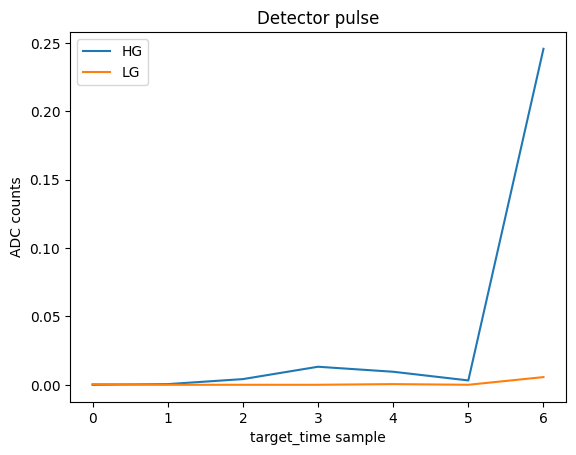

In [75]:
#Data vizualization and plotting of the first torch shard

sample = data['X'][0]

hg = sample[0]
lg = sample[1]

plt.plot(hg, label="HG")
plt.plot(lg, label="LG")

plt.xlabel("target_time sample")
plt.ylabel("ADC counts")
plt.title("Detector pulse")
plt.legend()
plt.show()

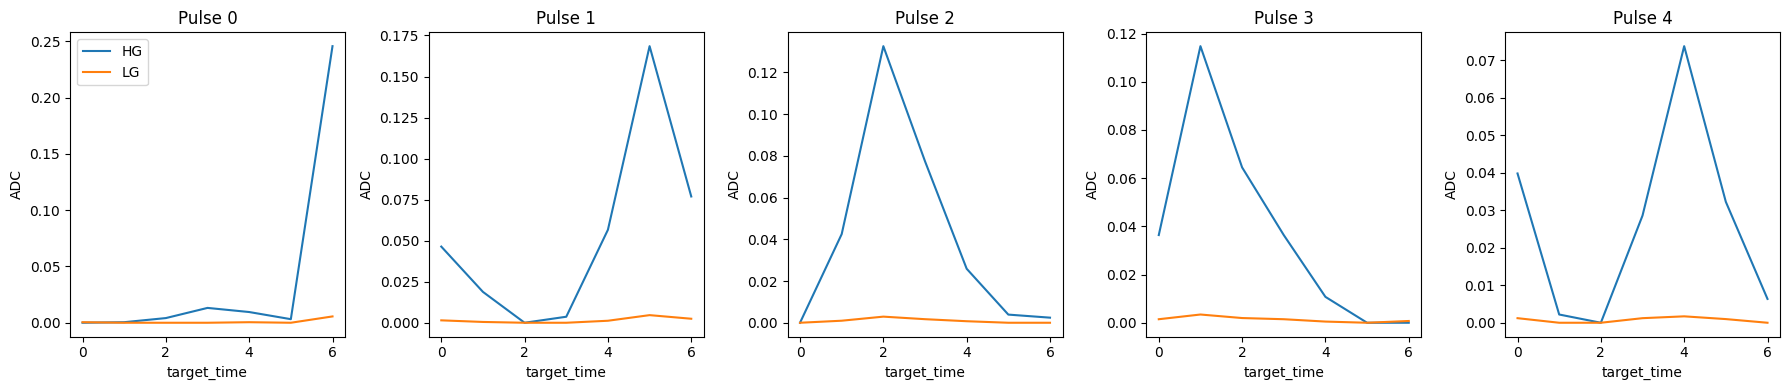

In [76]:
# plot for the first 5 pulse

fig, axes = plt.subplots(1, 5, figsize=(18,4))

for i in range(5):
    sample = data['X'][i]

    hg = sample[0]
    lg = sample[1]

    axes[i].plot(hg, label="HG")
    axes[i].plot(lg, label="LG")

    axes[i].set_title(f"Pulse {i}")
    axes[i].set_xlabel("target_time")
    axes[i].set_ylabel("ADC")

axes[0].legend()

plt.tight_layout()
plt.show()

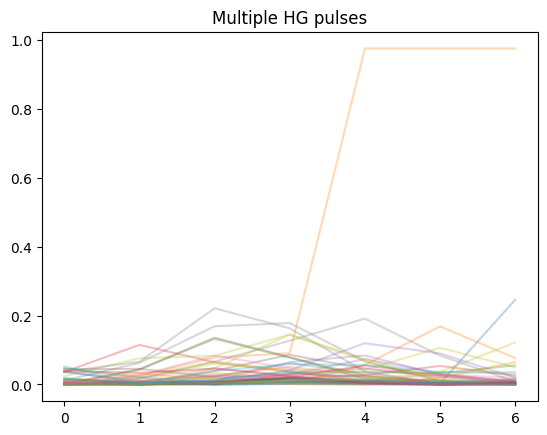

In [77]:
# plot for multiple hg pulses

for i in range(50):
    plt.plot(data['X'][i][0], alpha=0.3)

plt.title("Multiple HG pulses")
plt.show()

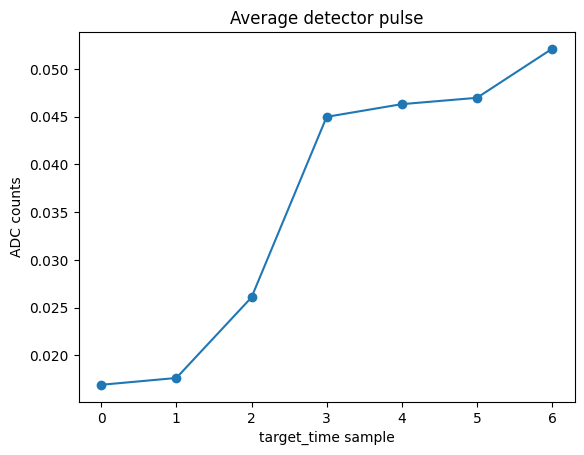

In [78]:
# average detector pulse plot

hg = data['X'][:,0,:].numpy()

mean_pulse = hg.mean(axis=0)

plt.plot(mean_pulse, marker="o")
plt.title("Average detector pulse")
plt.xlabel("target_time sample")
plt.ylabel("ADC counts")
plt.show()

In [79]:
#setting up random seed and device agnostic code

torch.manual_seed(54)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

DEVICE

'cuda'

In [ ]:
# torch dataset preparation and preprocessing

class TileCalDataset(Dataset):
    def __init__(self, dataDir, norm = False):
        
        self.files = sorted(glob.glob(f'{dataDir}/*.pt'))
        
        li_X = []
        li_y = []
        # li_y_of = []
        
        for file in self.files:
            data = torch.load(file)
            
            li_X.append(data['X'].float())
            li_y.append(data['y'].float())
            # li_y_of.append(data['y_OF'].float())
            
        
        X = torch.cat(li_X, dim=0)
        y = torch.cat(li_y, dim=0)
        # y_of = torch.cat(li_y_of, dim=0)
        
        self.X_hi = X[:, 0, :]
        self.X_lo = X[:, 1, :]
        self.y = y[:, 1]
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_hi[idx], self.X_lo[idx], self.y[idx]


In [81]:
# Linear Regression model construction

class LinearRegression(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        
        self.linear = nn.Linear(in_dim, 1)
        
        
    def forward(self, X):
        return self.linear(X)

In [82]:
# dataset partitioning and intialization for training val and test

train_dataset = TileCalDataset('../data/train')
val_dataset = TileCalDataset('../data/val')
test_dataset = TileCalDataset('../data/test')

In [83]:
#converting torch dataset objects to dataloader objects

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, drop_last=True, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False, pin_memory=True)

In [84]:
# defining helper functions for reusability

# training loop fucntion

def train(model, train_loader, optimizer, loss_fn, epochs, hi_gain=False):
    
    num_steps_per_epoch = len(train_loader)
    train_losses = []
    val_losses = []
    final_val_trues = []
    final_val_preds = []
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        progbar = Progbar(target=num_steps_per_epoch)
        
        #trainig phase

        model.train()
        running_loss = 0.0
        
        for batch_idx, (batch_features_hi, batch_features_lo, y_true) in enumerate(train_loader, 1):
            
            if hi_gain:
                batch_features_hi, batch_features_lo, y_true = batch_features_hi.to(DEVICE), batch_features_lo.to(DEVICE), y_true.to(DEVICE)
                y_pred = model(batch_features_hi, batch_features_lo)
            else:
                batch_features_lo, y_true = batch_features_lo.to(DEVICE), y_true.to(DEVICE)
                y_pred = model(batch_features_lo)
            
            loss = loss_fn(y_pred, y_true.unsqueeze(1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            avg_loss = running_loss / batch_idx

            if batch_idx < num_steps_per_epoch:
                progbar.update(batch_idx, values=[("loss", avg_loss)])
    
        train_losses.append(avg_loss)            
    
        # validation phase
        
        if val_loader is not None:
            model.eval() 
            val_running_loss = 0.0
            
            is_final_epoch = (epoch == epochs - 1)
            
            with torch.no_grad(): 
                for val_idx, (val_feat_hi, val_feat_lo, val_y) in enumerate(val_loader, 1):
                    val_y = val_y.to(DEVICE)
                    
                    if hi_gain:
                        val_feat_hi, val_feat_lo = val_feat_hi.to(DEVICE), val_feat_lo.to(DEVICE)
                        val_pred = model(val_feat_hi, val_feat_lo)
                    else:
                        val_feat_lo = val_feat_lo.to(DEVICE)
                        val_pred = model(val_feat_lo)
                    
                    v_loss = loss_fn(val_pred, val_y.unsqueeze(1))
                    val_running_loss += v_loss.item()
                    
                    if is_final_epoch:
                        final_val_trues.append(val_y.detach().cpu().numpy())
                        final_val_preds.append(val_pred.detach().cpu().numpy())
            
            val_avg_loss = val_running_loss / len(val_loader)
            val_losses.append(val_avg_loss)
            progbar.update(num_steps_per_epoch, values=[("loss", avg_loss), ("val_loss", val_avg_loss)])
            
        else:
            progbar.update(num_steps_per_epoch, values=[("loss", avg_loss)])

    if val_loader is not None:
        final_val_trues = np.concatenate(final_val_trues, axis=0)
        final_val_preds = np.concatenate(final_val_preds, axis=0).squeeze()

    return train_losses, val_losses, final_val_trues, final_val_preds
    

In [110]:
def evaluate(model, test_loader, device, hi_gain=False):
    
    num_steps = len(test_loader)
    print("Evaluating Model...")
    progbar = Progbar(target=num_steps)

    model.eval()

    y_pred_list = []
    y_true_list = []

    with torch.no_grad():
        for batch_idx, (batch_features_hi, batch_features_lo, y_true) in enumerate(test_loader, 1):
            if hi_gain:
                batch_features_hi = batch_features_hi.to(device)
                batch_features_lo = batch_features_lo.to(device)
                y_true = y_true.to(device)
                
                outputs = model(batch_features_hi, batch_features_lo)
            
            else:
                batch_features_lo = batch_features_lo.to(device)
                y_true = y_true.to(device)
                
                outputs = model(batch_features_lo)

            y_pred_list.append(outputs.cpu())
            y_true_list.append(y_true.cpu())

            progbar.update(batch_idx)

    y_pred = torch.cat(y_pred_list).numpy().flatten()
    y_true = torch.cat(y_true_list).numpy().flatten()

    # Calculate standard metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate relative error metrics

    # denormalize ystats
    
    y_true = y_true * y_stats['std'][:, 1] + y_stats['mean'][:, 1]
    y_pred = y_pred * y_stats['std'][:, 1] + y_stats['mean'][:, 1]
    
    eps = 1e-8
    
    # Relative error
    relative_error = (y_pred - y_true) / (y_true + eps)

    # Mean value
    mean_relative_error = np.mean(relative_error)

    # RMS value
    rms_relative_error = np.sqrt(np.mean(relative_error**2))

    
    # Print results
    print(f"\nMSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"\nRelative Error Metrics:")
    print(f"Mean Relative Error: {mean_relative_error:.4f}")
    print(f"RMS Relative Error: {rms_relative_error:.4f}")

    return y_pred, y_true, mse, mae, r2, mean_relative_error, rms_relative_error

In [86]:
def generate_plot(plot_type, model_name, model=None, train_losses=None, val_losses=None,
                  y_true=None, y_pred=None, lr=None, l2_lambda=None, optimizer_name=None, loss_fn_name=None):

    save_dir = '../results/plots'
    os.makedirs(save_dir, exist_ok=True)
    filepath = os.path.join(save_dir, f"{model_name}_{plot_type}.png")

    def add_hyperparams_box(ax, position='right'):
        textstr = f'Model: {model_name}'
        if lr is not None:          textstr += f'\nLR: {lr}'
        if l2_lambda is not None:   textstr += f'\nL2: {l2_lambda}'
        if optimizer_name is not None: textstr += f'\nOptimizer: {optimizer_name}'
        if loss_fn_name is not None:   textstr += f'\nLoss: {loss_fn_name}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        x, ha = (0.02, 'left') if position == 'left' else (0.98, 'right')
        ax.text(x, 0.85, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment=ha, bbox=props)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Training Curves
    if plot_type == 'train':
        ax.plot(train_losses, label='Train Loss', color='blue', lw=2)
        if val_losses:
            ax.plot(val_losses, label='Val Loss', color='orange', lw=2)
        ax.set_title('Training Curves', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        add_hyperparams_box(ax, position='right')

    #  Predictions vs True  
    elif plot_type == 'accuracy':
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.scatter(y_true, y_pred, alpha=0.5, color='royalblue', edgecolors='none')
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
        ax.set_title('Predictions vs True', fontweight='bold')
        ax.set_xlabel('True Signal Energy')
        ax.set_ylabel('Predicted Signal Energy')
        ax.legend()
        add_hyperparams_box(ax, position='left')

    # Model Weights Distribution  
    elif plot_type == 'weights':
        weights = np.concatenate([p.detach().cpu().numpy().flatten()
                                  for p in model.parameters() if p.requires_grad])
        ax.hist(weights, bins=50, color='teal', alpha=0.7, edgecolor='black')
        ax.set_title('Model Weights Distribution', fontweight='bold')
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Frequency')
        add_hyperparams_box(ax, position='right')

    # Absolute Error by True Energy  
    elif plot_type == 'error_by_energy':
        abs_error = np.abs(y_true - y_pred)
        ax.scatter(y_true, abs_error, alpha=0.5, color='coral', edgecolors='none')
        ax.set_title('Absolute Error by True Energy', fontweight='bold')
        ax.set_xlabel('True Signal Energy')
        ax.set_ylabel('Absolute Error')
        add_hyperparams_box(ax, position='right')

    #  Relative Error Distribution (1D density) 
    elif plot_type == 'relative_error':
        mask = y_true > 1.0
        relative_error = (y_pred[mask] - y_true[mask]) / y_true[mask]
        ax.hist(relative_error, bins=100, density=True, color='green', alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(relative_error), color='r', linestyle='--', label=f'Mean: {np.mean(relative_error):.4f}')
        ax.set_title('Relative Error Distribution', fontweight='bold')
        ax.set_xlabel('(E_pred - E_true) / E_true')
        ax.set_ylabel('Density')
        ax.legend()
        add_hyperparams_box(ax, position='right')

    # 2D Relative Error vs True Energy  
    elif plot_type == 'relative_error_2d':
        if isinstance(y_true, torch.Tensor): y_true = y_true.cpu().numpy()
        if isinstance(y_pred, torch.Tensor): y_pred = y_pred.cpu().numpy()

        mask = y_true > 1.0
        y_true_v, y_pred_v = y_true[mask], y_pred[mask]
        relative_error = (y_pred_v - y_true_v) / y_true_v

        rel_err_min, rel_err_max = -2.5, 2.5
        clip_mask = (relative_error >= rel_err_min) & (relative_error <= rel_err_max)
        y_true_plot = y_true_v[clip_mask]
        rel_err_plot = relative_error[clip_mask]

        x_min, x_max = 0, np.percentile(y_true_plot, 99.5)

        # 2D histogram with log color scale
        h = ax.hist2d(y_true_plot, rel_err_plot,
                      bins=[200, 100],
                      range=[[x_min, x_max], [rel_err_min, rel_err_max]],
                      cmap='jet', norm=LogNorm(vmin=1, vmax=1e5), cmin=1)
        cbar = plt.colorbar(h[3], ax=ax)
        cbar.set_label('Counts', rotation=270, labelpad=15)

        ax.axhline(0, color='white', linestyle='-', lw=1, alpha=0.7)

        # Bin mean ± σ overlay (red crosses)
        x_edges = np.linspace(x_min, x_max, 31)
        bin_centers, bin_means, bin_stds = [], [], []
        for i in range(30):
            in_bin = (y_true_plot >= x_edges[i]) & (y_true_plot < x_edges[i + 1])
            if in_bin.sum() > 10:
                bin_centers.append((x_edges[i] + x_edges[i + 1]) / 2)
                bin_means.append(rel_err_plot[in_bin].mean())
                bin_stds.append(rel_err_plot[in_bin].std())

        ax.errorbar(bin_centers, bin_means, yerr=bin_stds,
                    fmt='+', color='red', markersize=8, lw=2,
                    label='Bin mean ± σ', capsize=3, alpha=0.8)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(rel_err_min, rel_err_max)
        ax.set_xlabel('E_true [ADC Counts]', fontsize=11)
        ax.set_ylabel('(E_pred - E_true) / E_true', fontsize=11)
        ax.set_title('Relative Error vs True Energy', fontweight='bold', fontsize=12)
        ax.legend(loc='upper right', fontsize=9)
        add_hyperparams_box(ax, position='right')


    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {filepath}")

In [87]:
# baseline linear regression model hyperparams

base_model = LinearRegression(in_dim=7).to(DEVICE)
base_loss_fn = nn.MSELoss()
base_optimizer = optim.Adam(base_model.parameters(), lr=1e-3)
base_epochs = 100

In [88]:
# training baseline linear regression model using the above created trainig function

train_losses, val_losses, final_val_trues, final_val_preds = train(model=base_model, train_loader=train_loader, optimizer=base_optimizer, loss_fn=base_loss_fn, epochs=base_epochs)


Epoch 1/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9750 - val_loss: 0.9583

Epoch 2/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9467 - val_loss: 0.9355

Epoch 3/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.9210 - val_loss: 0.9161

Epoch 4/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9040 - val_loss: 0.8986

Epoch 5/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8919 - val_loss: 0.8828

Epoch 6/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8748 - val_loss: 0.8681

Epoch 7/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8610 - val_loss: 0.8544

Epoch 8/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8491 - val_loss: 0.8411

Epoch 9/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8340 - val_loss: 0.8281

Epoch 10/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8225 - val_loss: 0.8155

Epoch 11/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.8109 - val_loss: 0.8030

Epoch 12/100
521/5

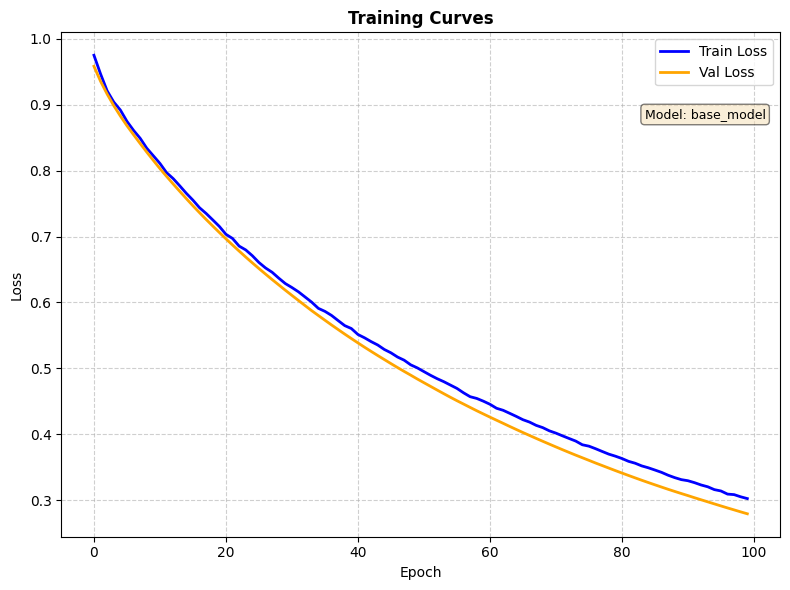

Saved: ../results/plots\base_model_train.png


In [89]:
#plotting the baseline model's plots
generate_plot(plot_type='train', model_name = 'base_model', model=base_model, train_losses=train_losses, val_losses=val_losses)


In [90]:
# evaluating baseline linear regression model using the above created trainig function

y_pred, y_true, mse, mae, r2, *_ = evaluate(model = base_model, test_loader = test_loader, device = DEVICE, hi_gain=False)

Evaluating Model...
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

MSE: 0.3240
MAE: 0.0632
R² Score: 0.7263

Relative Error Metrics:
Mean Relative Error: 2.4496
RMS Relative Error: 30.3146


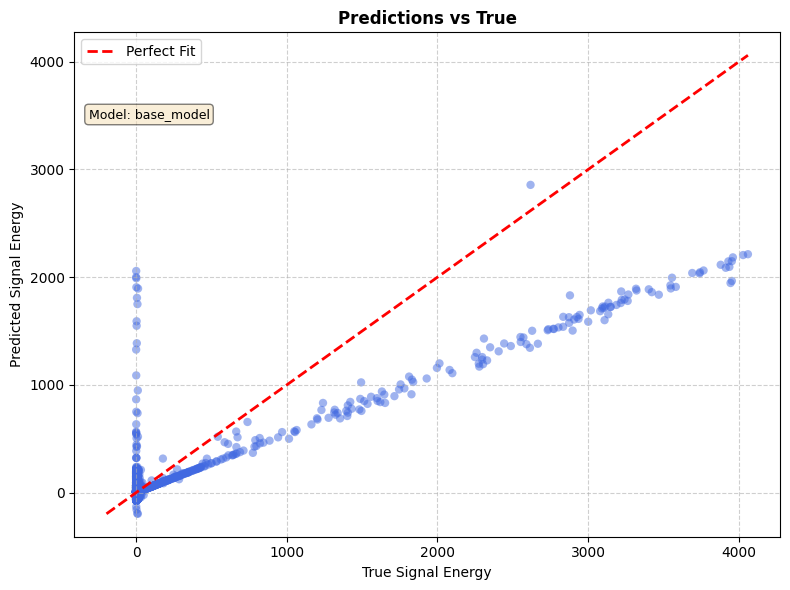

Saved: ../results/plots\base_model_accuracy.png


In [91]:
generate_plot(plot_type='accuracy', model_name = 'base_model', model=base_model, train_losses=train_losses, val_losses=val_losses, y_true=y_true, y_pred=y_pred)

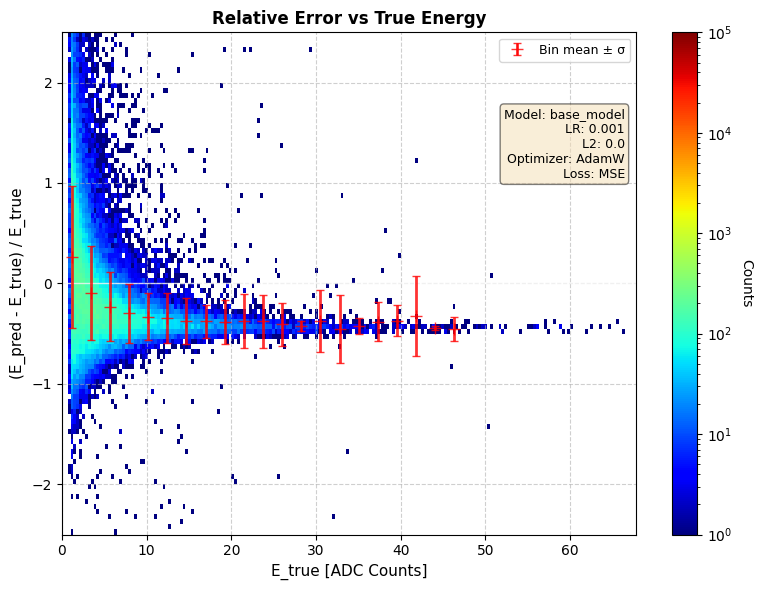

Saved: ../results/plots\base_model_relative_error_2d.png


In [92]:
generate_plot(plot_type='relative_error_2d', 
              model_name = 'base_model', 
              model=base_model, 
              y_true=y_true, 
              y_pred=y_pred,
              lr=1e-3,
              l2_lambda=0.0,
              loss_fn_name='MSE',
              optimizer_name='AdamW')

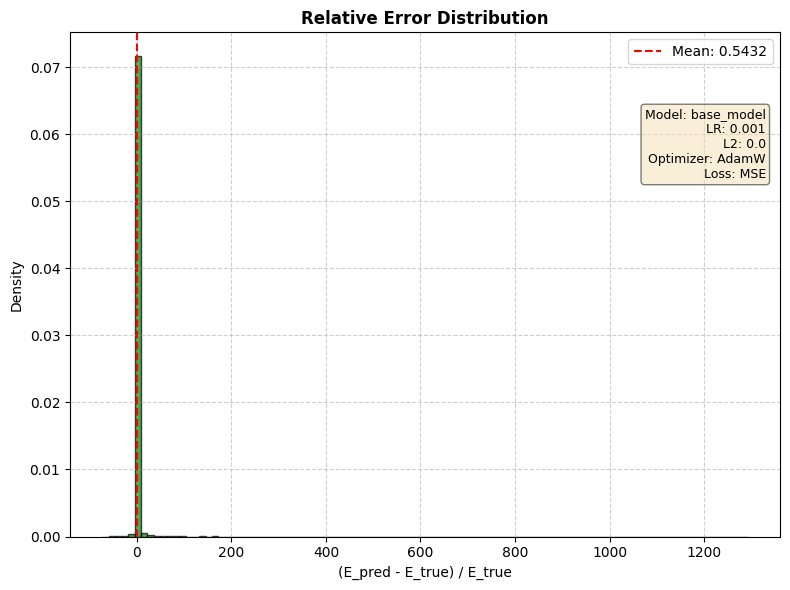

Saved: ../results/plots\base_model_relative_error.png


In [93]:
generate_plot(plot_type='relative_error', 
              model_name = 'base_model', 
              model=base_model, 
              y_true=y_true, 
              y_pred=y_pred,
              lr=1e-3,
              l2_lambda=0.0,
              loss_fn_name='MSE',
              optimizer_name='AdamW')

In [94]:
# Ridge regression hyperparams 

model_ridge = LinearRegression(in_dim=7).to(DEVICE)
ridge_loss_fn = nn.MSELoss()
l2_lambda = 1e-3
ridge_optimizer = optim.AdamW(model_ridge.parameters(), lr=9e-3, weight_decay=l2_lambda)
epochs = 120


In [95]:
# Training ridge regression model using the above created trainig function

train_losses, val_losses, final_val_trues, final_val_preds = train(model=model_ridge, train_loader=train_loader, optimizer=ridge_optimizer, loss_fn=ridge_loss_fn, epochs=epochs)


Epoch 1/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9089 - val_loss: 0.8438

Epoch 2/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.7950 - val_loss: 0.7455

Epoch 3/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.7105 - val_loss: 0.6664

Epoch 4/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.6408 - val_loss: 0.5996

Epoch 5/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5817 - val_loss: 0.5425

Epoch 6/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5308 - val_loss: 0.4934

Epoch 7/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.4859 - val_loss: 0.4503

Epoch 8/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.4479 - val_loss: 0.4128

Epoch 9/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.4136 - val_loss: 0.3780

Epoch 10/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3819 - val_loss: 0.3468

Epoch 11/120
521/521 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3536 - val_loss: 0.3197

Epoch 12/120
521/5

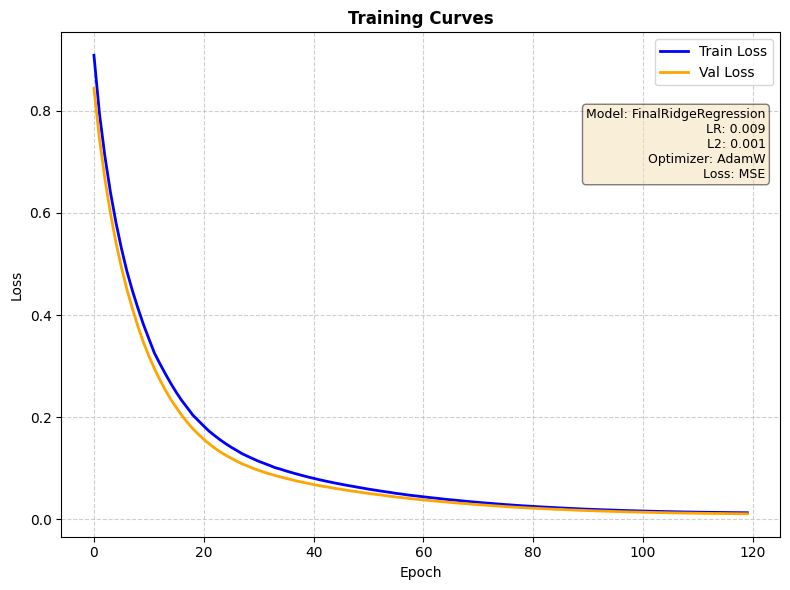

Saved: ../results/plots\FinalRidgeRegression_train.png


In [96]:
generate_plot(plot_type='train', 
              model_name = 'FinalRidgeRegression', 
              model=model_ridge, 
              train_losses=train_losses, 
              val_losses=val_losses,
              lr=9e-3,
              l2_lambda=1e-3,
              loss_fn_name='MSE',
              optimizer_name='AdamW')

In [111]:
y_pred, y_true, mse, mae, r2, mean_relative_error, rms_relative_error = evaluate(model = model_ridge, test_loader = test_loader, device = DEVICE, hi_gain=False)

Evaluating Model...
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

MSE: 0.0111
MAE: 0.0302
R² Score: 0.9906

Relative Error Metrics:
Mean Relative Error: 0.4122
RMS Relative Error: 10.0534


In [138]:
print(f"y_true range: {np.min(y_true):.4f} to {np.max(y_true):.4f}")
print(f"y_pred range: {np.min(y_pred):.4f} to {np.max(y_pred):.4f}")
print(f"Sample errors: {np.abs(y_pred[:10] - y_true[:10])}")
print(f"Sample relative errors: {np.abs((y_pred[:10] - y_true[:10]) / y_true[:10])}")

y_true range: 0.2500 to 4060.4973
y_pred range: -192.1248 to 3924.7715
Sample errors: [2.8382645  1.3019154  0.7319541  1.0521517  1.2793126  0.10164213
 2.0734727  2.489887   2.1038265  4.377543  ]
Sample relative errors: [0.7512604  0.67873627 1.0306208  3.7268429  0.25359607 0.34371835
 5.3078117  7.8755035  1.1642448  2.752563  ]


In [139]:
rel_errors = np.abs((y_pred - y_true) / y_true)
print(f"Max relative error: {np.max(rel_errors):.4f}")
print(f"99th percentile: {np.percentile(rel_errors, 99):.4f}")
print(f"How many > 1.0: {np.sum(rel_errors > 1.0)}")

Max relative error: 760.2068
99th percentile: 24.0225
How many > 1.0: 50867


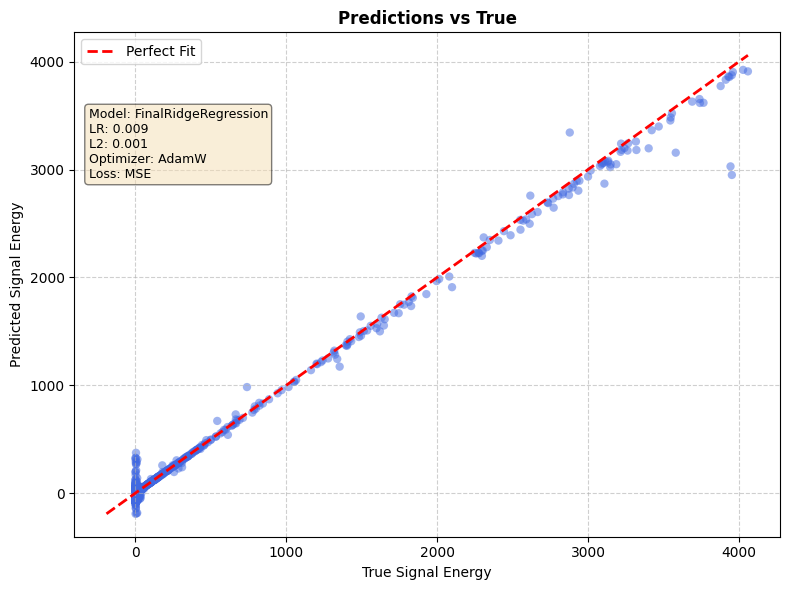

Saved: ../results/plots\FinalRidgeRegression_accuracy.png


In [98]:
generate_plot(plot_type='accuracy', 
              model_name = 'FinalRidgeRegression', 
              model=model_ridge, 
              train_losses=train_losses, 
              val_losses=val_losses,
              y_true=y_true, 
              y_pred=y_pred,
              lr=9e-3,
              l2_lambda=1e-3,
              loss_fn_name='MSE',
              optimizer_name='AdamW')

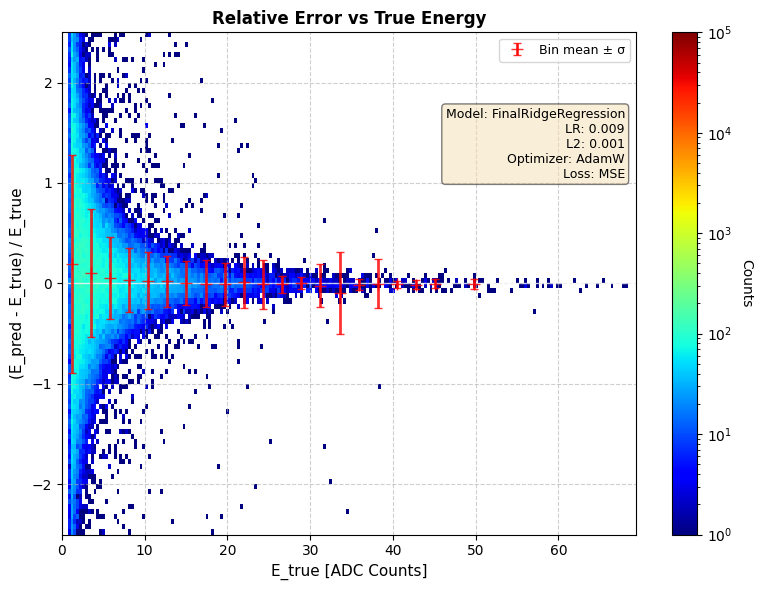

Saved: ../results/plots\FinalRidgeRegression_relative_error_2d.png


In [99]:
generate_plot(plot_type='relative_error_2d', 
              model_name = 'FinalRidgeRegression', 
              model=model_ridge, 
              train_losses=train_losses, 
              val_losses=val_losses,
              y_true=y_true, 
              y_pred=y_pred,
              lr=9e-3,
              l2_lambda=1e-3,
              loss_fn_name='MSE',
              optimizer_name='AdamW')

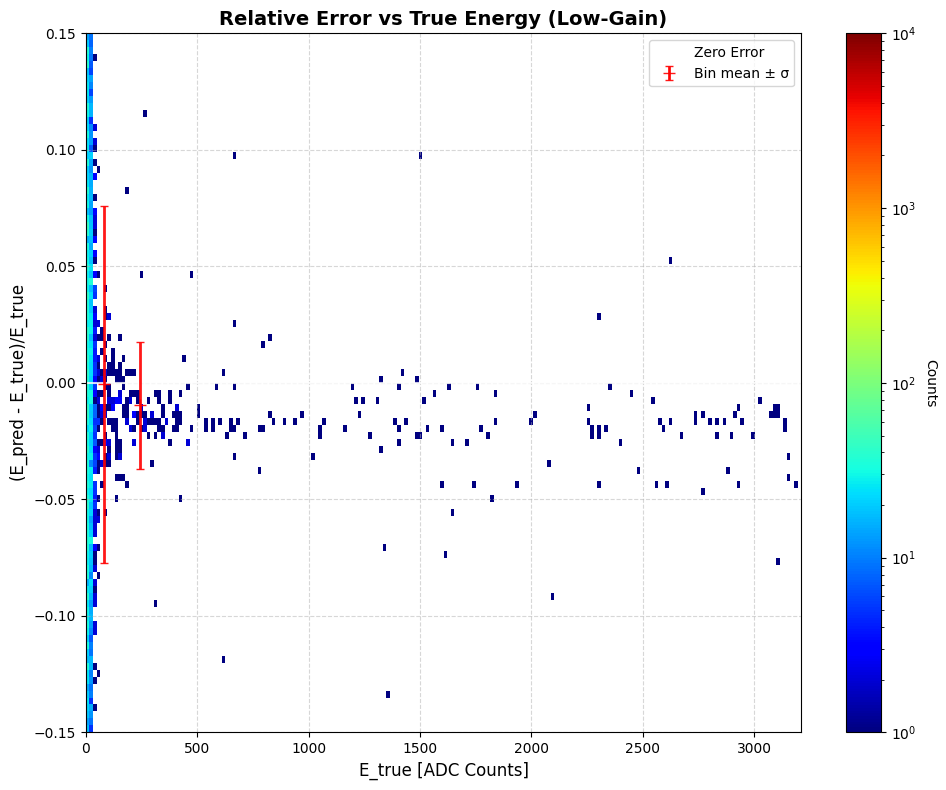

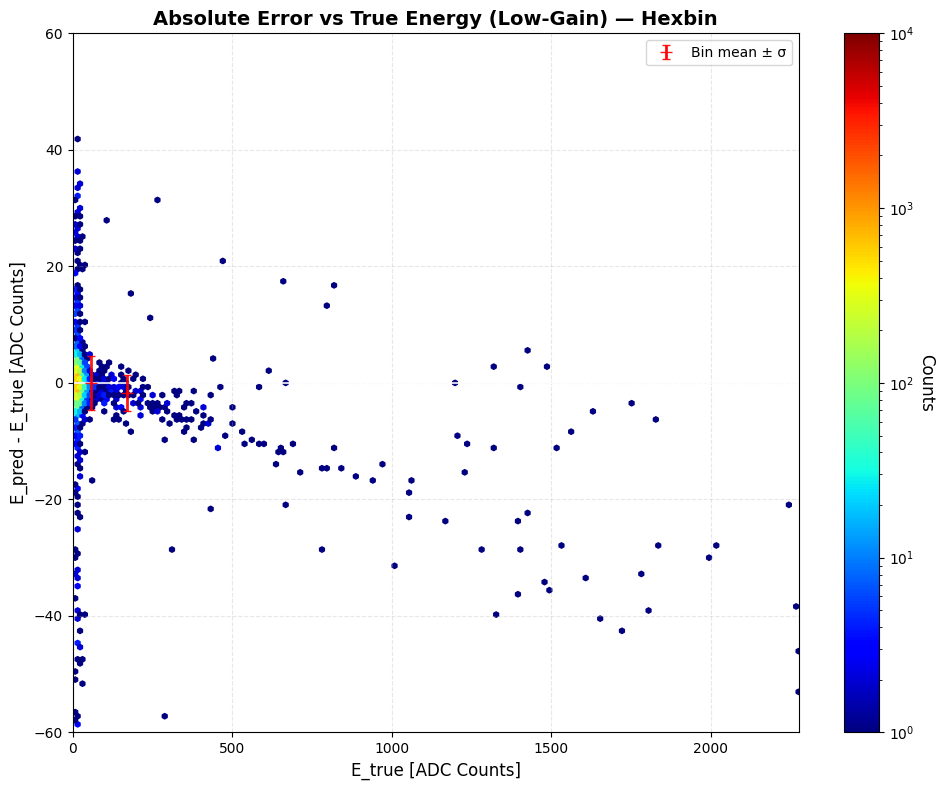

In [ ]:
# relative error graph without clipping
save_dir = '../results/plots'
energy_threshold = 10.0
valid_mask = y_true > energy_threshold
y_true_valid = y_true[valid_mask]
y_pred_valid = y_pred[valid_mask]
relative_error = (y_pred_valid - y_true_valid) / y_true_valid

rel_err_min, rel_err_max = -0.15, 0.15
clip_mask = (relative_error >= rel_err_min) & (relative_error <= rel_err_max)
y_true_plot = y_true_valid[clip_mask]
rel_err_plot = relative_error[clip_mask]

fig, ax = plt.subplots(figsize=(10, 8))
x_max = min(np.percentile(y_true_plot, 99.5), 4000)
x_min = 0

h = ax.hist2d(
    y_true_plot, rel_err_plot,
    bins=[200, 100],
    range=[[x_min, x_max], [rel_err_min, rel_err_max]],
    cmap='jet',
    norm=LogNorm(vmin=1, vmax=1e4),
    cmin=1
)

cbar = plt.colorbar(h[3], ax=ax)
cbar.set_label('Counts', rotation=270, labelpad=15)
ax.axhline(0, color='white', linestyle='-', lw=1.5, alpha=0.8, label='Zero Error')

n_bins = 20
x_edges = np.linspace(x_min, x_max, n_bins + 1)
bin_centers, bin_means, bin_stds = [], [], []

for i in range(n_bins):
    in_bin = (y_true_plot >= x_edges[i]) & (y_true_plot < x_edges[i + 1])
    if in_bin.sum() > 50:
        bin_centers.append((x_edges[i] + x_edges[i + 1]) / 2)
        bin_means.append(rel_err_plot[in_bin].mean())
        bin_stds.append(rel_err_plot[in_bin].std())

bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)

ax.errorbar(bin_centers, bin_means, yerr=bin_stds,
    fmt='+', color='red', markersize=8, lw=2,
    label='Bin mean ± σ', capsize=3, alpha=0.9)

ax.set_xlim(x_min, x_max)
ax.set_ylim(rel_err_min, rel_err_max)
ax.set_xlabel('E_true [ADC Counts]', fontsize=12)
ax.set_ylabel('(E_pred - E_true)/E_true', fontsize=12)
ax.set_title('Relative Error vs True Energy (Low-Gain)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{save_dir}/finalRidgeRegression_relative_error_2d_LG.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

abs_error = y_pred_valid - y_true_valid
abs_err_min, abs_err_max = -60, 60
clip_mask_abs = (abs_error >= abs_err_min) & (abs_error <= abs_err_max)
y_true_abs = y_true_valid[clip_mask_abs]
abs_err_plot = abs_error[clip_mask_abs]

x_min_abs = 0
x_max_abs = min(np.percentile(y_true_abs, 99.5), 4000)

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hexbin(
    y_true_abs, abs_err_plot,
    gridsize=150,
    extent=[x_min_abs, x_max_abs, abs_err_min, abs_err_max],
    cmap='jet',
    norm=LogNorm(vmin=1, vmax=1e4),
    mincnt=1
)

cbar = plt.colorbar(h, ax=ax)
cbar.set_label('Counts', rotation=270, labelpad=15, fontsize=12)
ax.axhline(0, color='white', linestyle='-', lw=1.5, alpha=0.8)

x_edges_abs = np.linspace(x_min_abs, x_max_abs, n_bins + 1)
bin_centers_abs, bin_means_abs, bin_stds_abs = [], [], []

for i in range(n_bins):
    in_bin = (y_true_abs >= x_edges_abs[i]) & (y_true_abs < x_edges_abs[i + 1])
    if in_bin.sum() > 50:
        bin_centers_abs.append((x_edges_abs[i] + x_edges_abs[i + 1]) / 2)
        bin_means_abs.append(abs_err_plot[in_bin].mean())
        bin_stds_abs.append(abs_err_plot[in_bin].std())

bin_centers_abs = np.array(bin_centers_abs)
bin_means_abs   = np.array(bin_means_abs)
bin_stds_abs    = np.array(bin_stds_abs)

ax.errorbar(bin_centers_abs, bin_means_abs, yerr=bin_stds_abs,
    fmt='+', color='red', markersize=8, lw=2,
    capsize=3, alpha=0.9, label='Bin mean ± σ')

ax.set_xlim(x_min_abs, x_max_abs)
ax.set_ylim(abs_err_min, abs_err_max)
ax.set_xlabel('E_true [ADC Counts]', fontsize=12)
ax.set_ylabel('E_pred - E_true [ADC Counts]', fontsize=12)
ax.set_title('Absolute Error vs True Energy (Low-Gain) — Hexbin', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{save_dir}/finalRidgeRegression_absolute_error_hexbin_LG.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

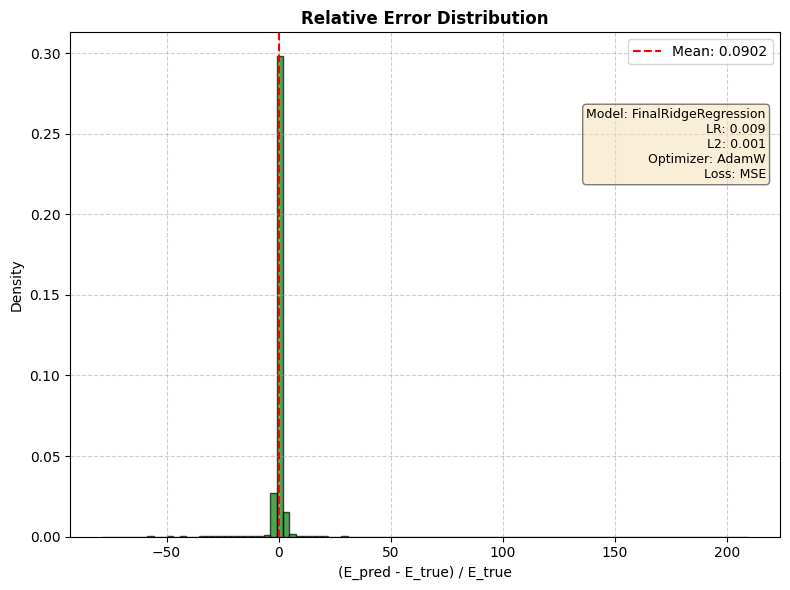

Saved: ../results/plots\FinalRidgeRegression_relative_error.png


In [140]:
generate_plot(plot_type='relative_error', 
              model_name = 'FinalRidgeRegression', 
              model=model_ridge, 
              train_losses=train_losses, 
              val_losses=val_losses,
              y_true=y_true, 
              y_pred=y_pred,
              lr=9e-3,
              l2_lambda=1e-3,
              loss_fn_name='MSE',
              optimizer_name='AdamW') 

In [143]:
torch.save(model_ridge.state_dict(), "../results/models/final_ridge_regression.pth")

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_of, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_of, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")